# ResNet-18 PTQ Analysis — Test Set

In [13]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from utils import load_runs, flatten_runs, print_run_summary

In [ ]:
runs = load_runs('../runs/final_runs', status='ok')
df   = pd.DataFrame(flatten_runs(runs))

df['backend']    = df['cfg.backend']
df['precision']  = df['cfg.model_precision']
df['input_bits'] = df['cfg.input_quant_bits'].fillna(0).astype(int)
df['top1']       = df['res.top1_acc']
df['top5']       = df['res.top5_acc']
df['lat_ms']     = df['res.infer_ms_avg']
df['lat_std']    = df['res.infer_ms_std']
df['tput']       = df['res.throughput_infer_sps']

print(f'{len(df)} runs loaded')

In [15]:
table = (
    df[['backend','precision','input_bits','top1','top5','lat_ms','lat_std','tput']]
    .sort_values(['backend','input_bits', 'precision'])
    .reset_index(drop=True)
)

In [16]:
table

,backend,precision,input_bits,top1,top5,lat_ms,lat_std,tput
0,pytorch,fp16,1,26.595745,56.595745,2.782924,1.437998,359.334227
1,pytorch,fp32,1,26.595745,56.595745,2.869502,1.344205,348.492504
2,pytorch,fp16,2,49.787234,77.659574,2.688799,1.278557,371.913222
3,pytorch,fp32,2,49.787234,77.659574,2.818630,1.325444,354.782249
4,pytorch,fp16,4,80.638298,96.170213,2.809120,1.537328,355.983392
5,pytorch,fp32,4,80.851064,96.170213,2.698732,1.217125,370.544390
6,pytorch,fp16,8,83.829787,96.595745,2.885167,1.383255,346.600371
7,pytorch,fp32,8,83.829787,96.595745,3.093748,1.476282,323.232546
8,tensorrt,fp16,1,26.595745,56.595745,0.484740,0.183497,2062.962414
9,tensorrt,fp32,1,26.595745,56.595745,0.964126,0.153792,1037.208448


In [17]:
BACKENDS = ["pytorch", "tensorrt"]
COLS     = 2
eb_kw    = dict(capsize=3, capthick=0.8, elinewidth=0.8, linewidth=0)

BIT_PALETTE = {
    1: "#1f77b4",
    2: "#d62728",
    4: "#2ca02c",
    8: "#9467bd",
}

PREC_PALETTE = {
    "fp8":  "#1f77b4",
    "fp16": "#d62728",
    "fp32": "#2ca02c",
    "int4": "#9467bd",
    "int8": "#8c564b",
}

def make_figure(backend, n):
    """Create a figure with a 2-col grid for a given backend. Returns flat axes array."""
    nrows = math.ceil(n / COLS)
    fig, axes = plt.subplots(
        nrows, COLS,
        figsize=(4.5 * COLS, 3.8 * nrows),
        constrained_layout=True,
        squeeze=False,
    )
    fig.suptitle(backend, fontsize=12, fontweight="normal",
                 x=0.5, ha="center", y=1.04)
    fig.set_constrained_layout_pads(wspace=0.15, hspace=0.1)
    ax_flat = axes.flatten()
    for idx in range(n, len(ax_flat)):
        ax_flat[idx].set_visible(False)
    return ax_flat

def draw_bars(ax, grp, x_col, palette):
    """Draw bars + error bars + latency labels for one subplot."""
    x_vals = grp[x_col].tolist()
    x_pos  = np.arange(len(x_vals))
    for xi, (_, row) in enumerate(grp.iterrows()):
        c = palette.get(row[x_col] if isinstance(row[x_col], str) else int(row[x_col]), "#7f7f7f")
        ax.bar(xi, row["lat_ms"], color=c + "55", edgecolor=c,
               linewidth=0.9, width=0.6, zorder=2)
        ax.errorbar(xi, row["lat_ms"], yerr=row["lat_std"],
                    fmt="none", ecolor=c, **eb_kw)
        ax.text(xi, row["lat_ms"] * 0.02, f"{row['lat_ms']:.3f}",
                ha="center", va="bottom", fontsize=7, color=c, zorder=3)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(v) for v in x_vals])
    ax.set_ylim(0, (grp["lat_ms"] + grp["lat_std"]).max() * 1.25)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)

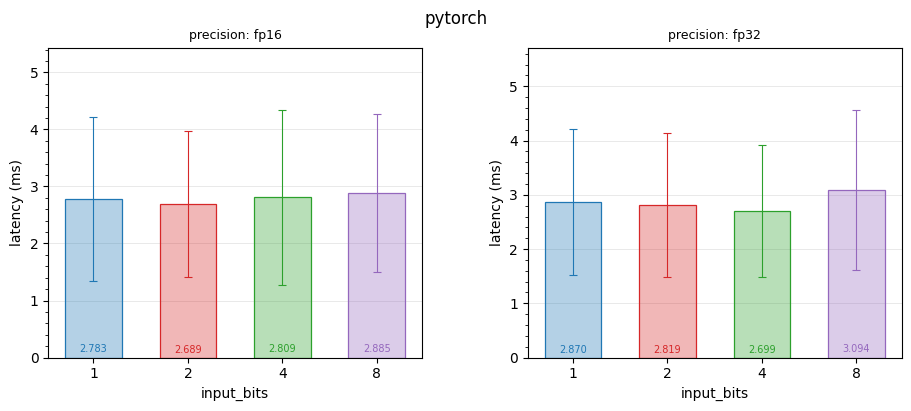

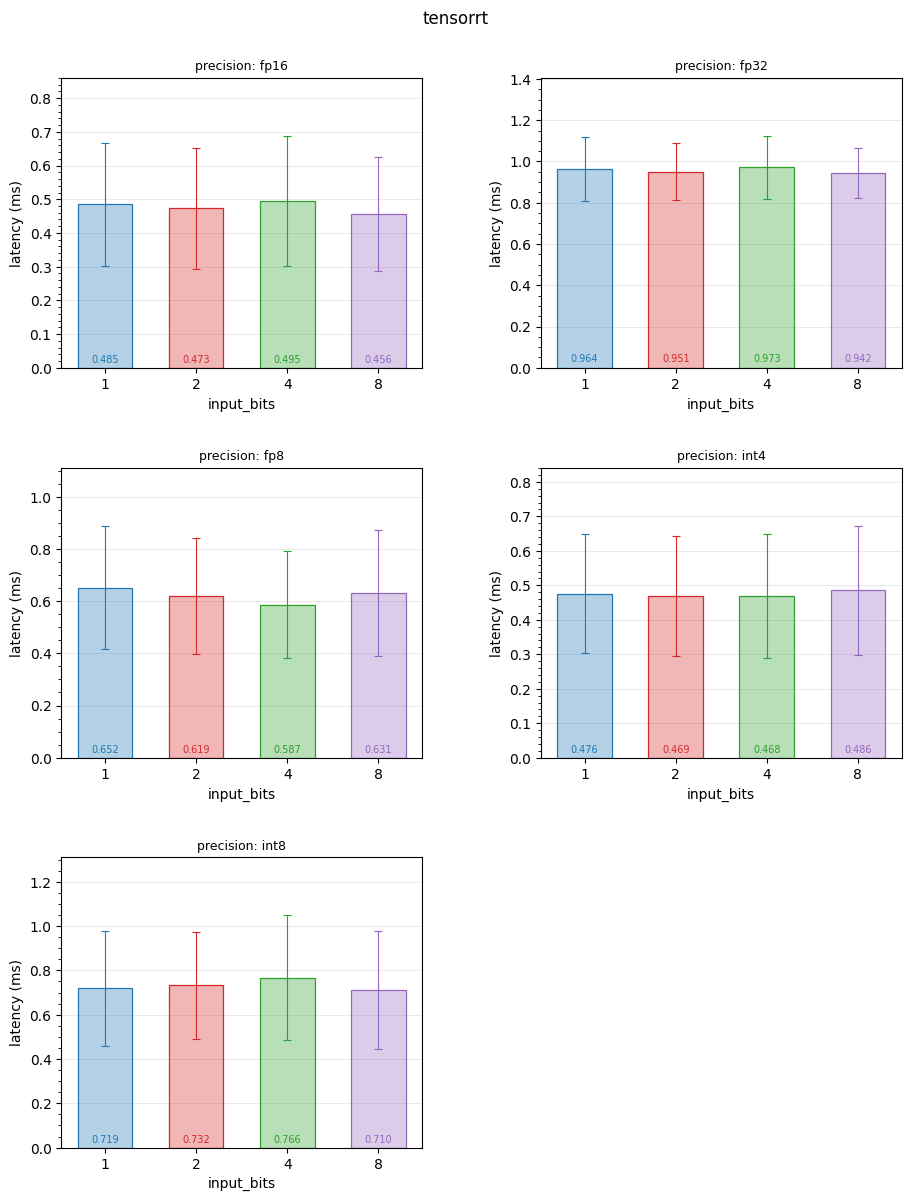

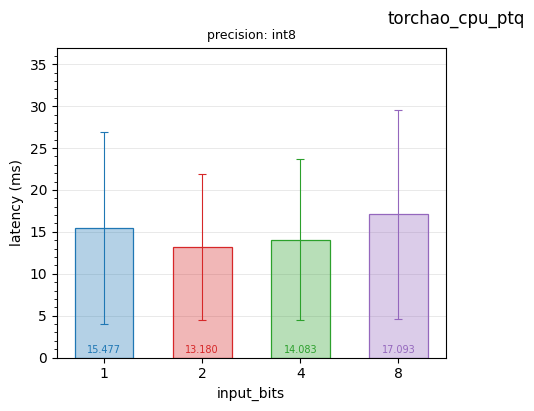

In [18]:
# Plot 1 — latency vs input quantization bits ──────────────────────
BACKENDS = ["pytorch", "tensorrt", "torchao_cpu_ptq"]
for backend in BACKENDS:
    backend_data      = table[table["backend"] == backend]
    active_precisions = sorted(backend_data["precision"].unique())
    n = len(active_precisions)
    if n == 0:
        continue

    ax_flat = make_figure(backend, n)

    for ax, prec in zip(ax_flat, active_precisions):
        grp = (
            backend_data[backend_data["precision"] == prec]
            .sort_values("input_bits")
            .dropna(subset=["input_bits", "lat_ms", "lat_std"])
        )
        if grp.empty:
            ax.set_visible(False)
            continue

        grp = grp.copy()
        grp["input_bits"] = grp["input_bits"].astype(int)

        draw_bars(ax, grp, x_col="input_bits", palette=BIT_PALETTE)
        ax.set_xlabel("input_bits")
        ax.set_ylabel("latency (ms)")
        ax.set_title(f"precision: {prec}", fontsize=9)

    plt.show()

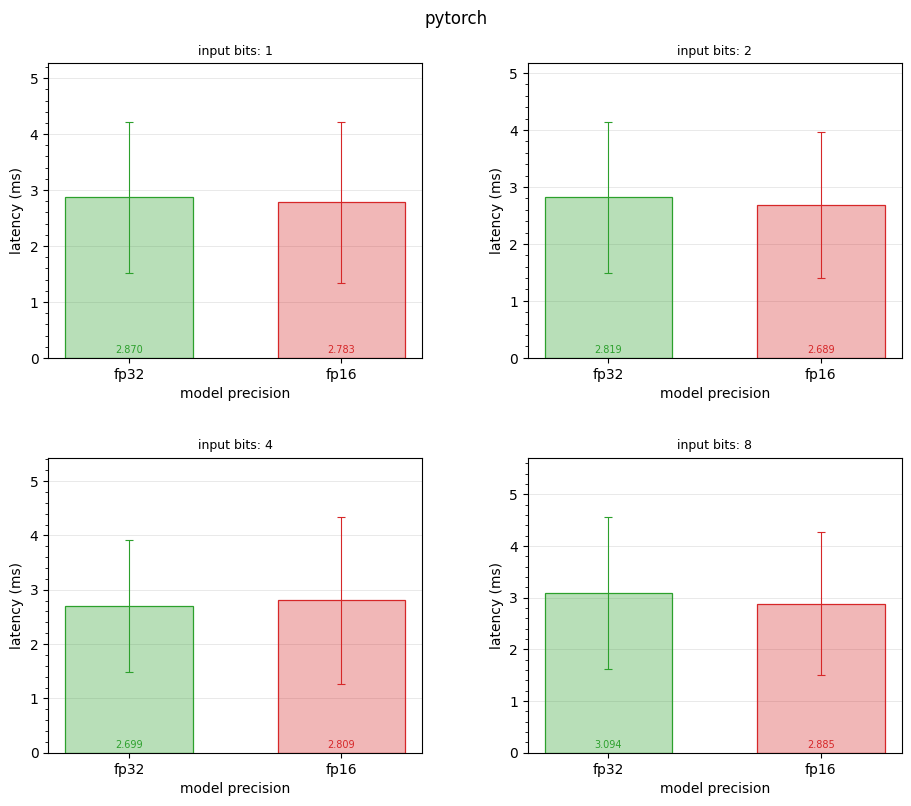

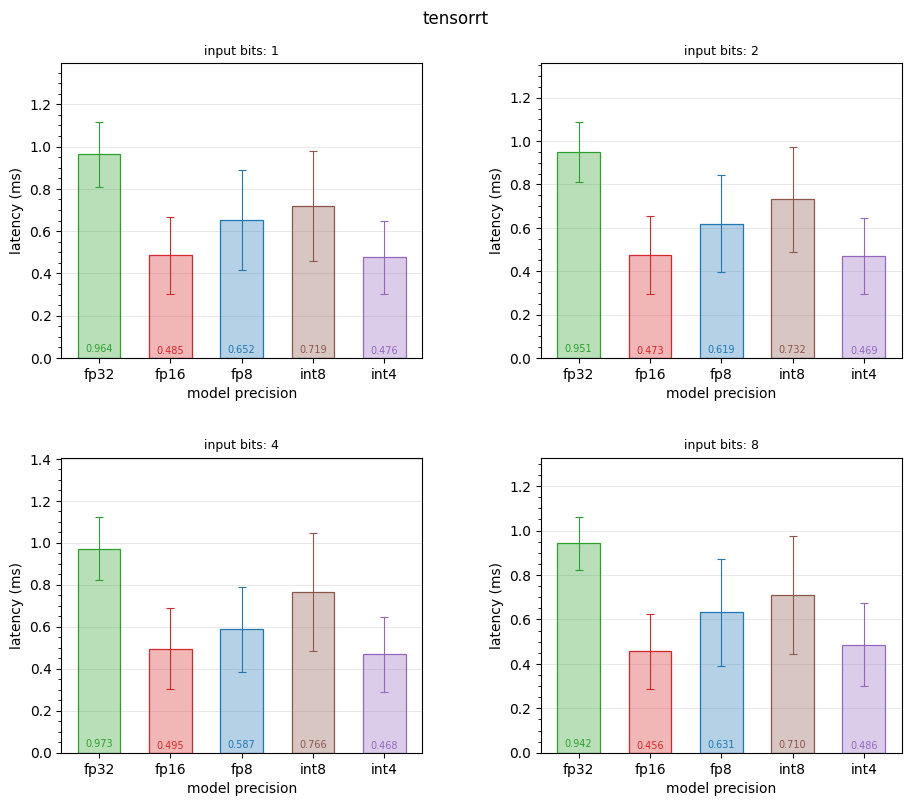

In [19]:
# ── Cell 3: Plot 2 — latency vs model precision ───────────────────────────────
BACKENDS = ["pytorch", "tensorrt"]
for backend in BACKENDS:
    backend_data = table[table["backend"] == backend]
    active_bits  = sorted(backend_data["input_bits"].dropna().astype(int).unique())
    n = len(active_bits)
    if n == 0:
        continue

    ax_flat = make_figure(backend, n)

    for ax, bits in zip(ax_flat, active_bits):
        PREC_ORDER = ["fp32", "fp16", "fp8", "int8", "int4"]

        grp = (
            backend_data[backend_data["input_bits"] == bits]
            .dropna(subset=["precision", "lat_ms", "lat_std"])
        )
        grp = grp.set_index("precision").reindex(PREC_ORDER).dropna(subset=["lat_ms"]).reset_index()
        if grp.empty:
            ax.set_visible(False)
            continue

        draw_bars(ax, grp, x_col="precision", palette=PREC_PALETTE)
        ax.set_xlabel("model precision")
        ax.set_ylabel("latency (ms)")
        ax.set_title(f"input bits: {bits}", fontsize=9)

    plt.show()

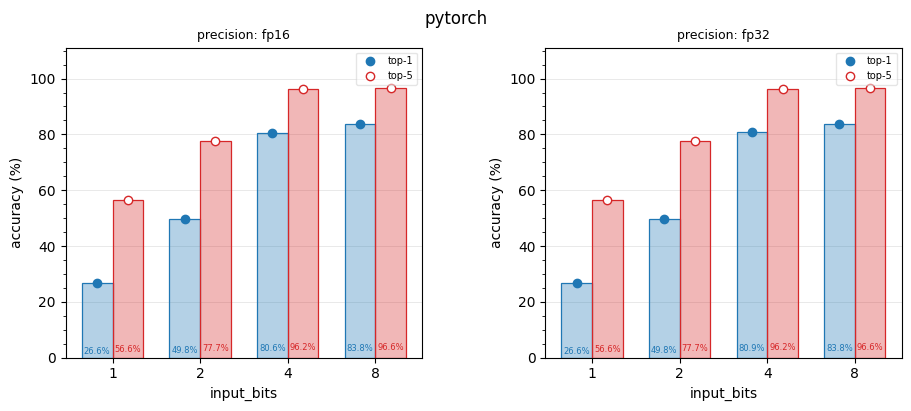

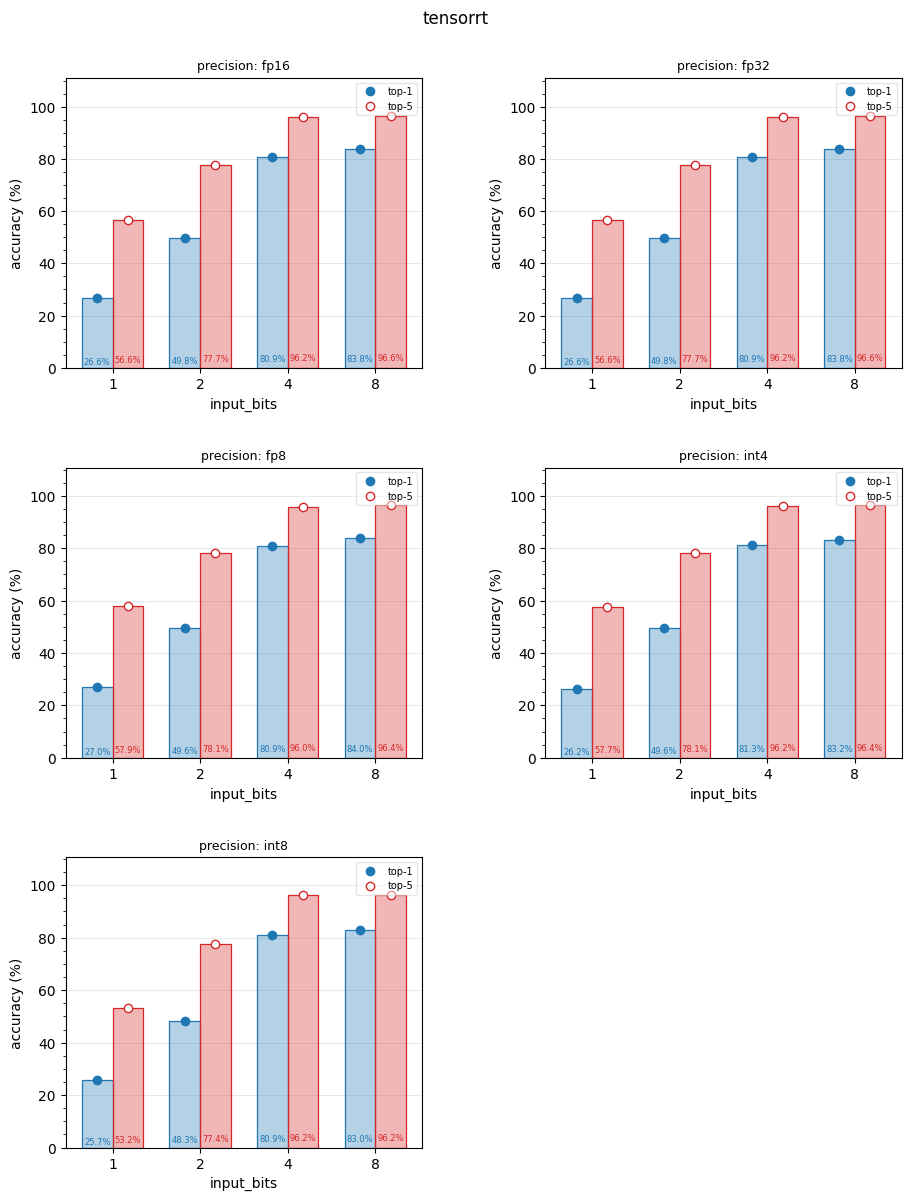

In [20]:
# ── Cell 4: Plot 3 — Top-1 & Top-5 accuracy vs input quantization bits ───────
for backend in BACKENDS:
    backend_data      = table[table["backend"] == backend]
    active_precisions = sorted(backend_data["precision"].unique())
    n = len(active_precisions)
    if n == 0:
        continue

    ax_flat = make_figure(backend, n)

    for ax, prec in zip(ax_flat, active_precisions):
        grp = (
            backend_data[backend_data["precision"] == prec]
            .sort_values("input_bits")
            .dropna(subset=["input_bits", "top1", "top5"])
        )
        if grp.empty:
            ax.set_visible(False)
            continue

        bits  = grp["input_bits"].astype(int).tolist()
        x_pos = np.arange(len(bits))

        # bars for top-1 and top-5, side by side
        width = 0.35
        ax.bar(x_pos - width/2, grp["top1"], width=width,
               color="#1f77b4" + "55", edgecolor="#1f77b4", linewidth=0.9, zorder=2)
        ax.bar(x_pos + width/2, grp["top5"], width=width,
               color="#d62728" + "55", edgecolor="#d62728", linewidth=0.9, zorder=2)

        # markers on top of bars
        ax.plot(x_pos - width/2, grp["top1"], color="#1f77b4",
                marker="o", linestyle="none", markersize=6, label="top-1", zorder=3)
        ax.plot(x_pos + width/2, grp["top5"], color="#d62728",
                marker="o", linestyle="none", markersize=6,
                markerfacecolor="white", label="top-5", zorder=3)

        # percentage labels just above the baseline
        for xi, (_, row) in enumerate(grp.iterrows()):
            ax.text(xi - width/2, row["top1"] * 0.02, f"{row['top1']:.1f}%",
                    ha="center", va="bottom", fontsize=6, color="#1f77b4", zorder=4)
            ax.text(xi + width/2, row["top5"] * 0.02, f"{row['top5']:.1f}%",
                    ha="center", va="bottom", fontsize=6, color="#d62728", zorder=4)

        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(b) for b in bits])
        ax.set_xlabel("input_bits")
        ax.set_ylabel("accuracy (%)")
        ax.set_title(f"precision: {prec}", fontsize=9)
        ax.set_ylim(0, grp[["top1", "top5"]].max().max() * 1.15)
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)
        ax.legend(fontsize=7, framealpha=0.5)

    plt.show()

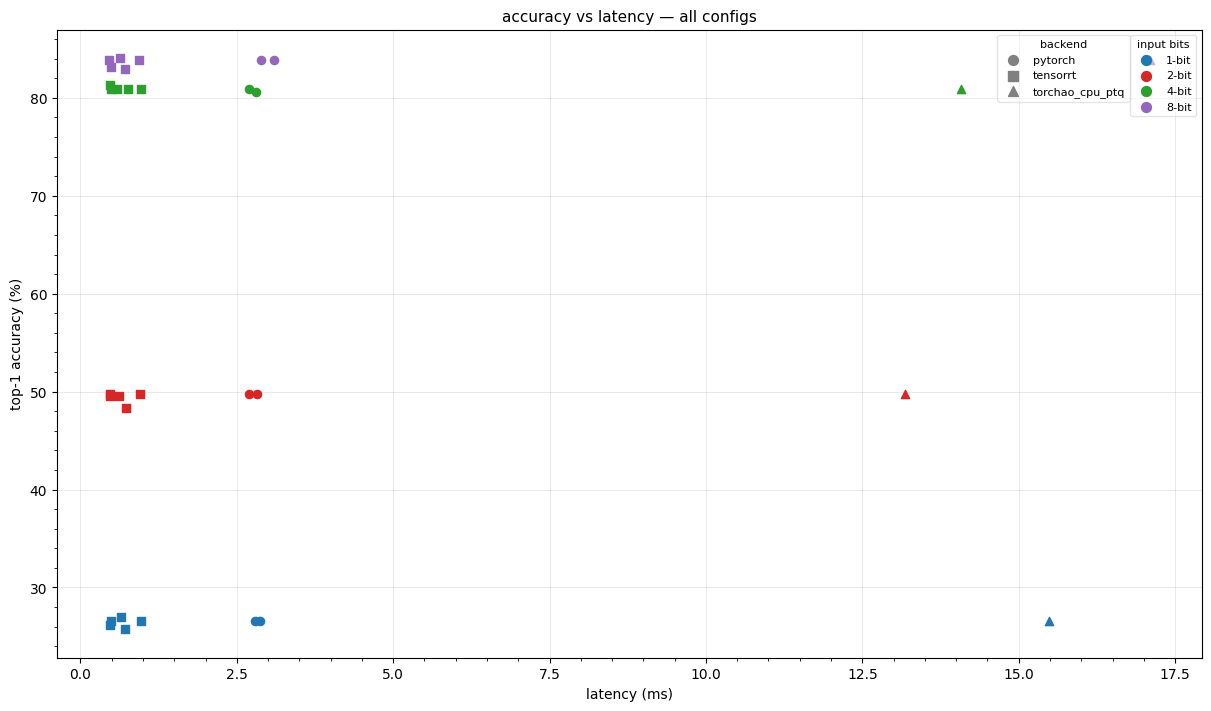

In [21]:
# ── Cell 5: Plot 4 — Top-1 accuracy vs latency scatter (all configs) ─────────

BACKEND_MARKERS = {
    "pytorch":         "o",
    "tensorrt":        "s",
    "torchao_cpu_ptq": "^",
}

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

for backend, bgrp in table.groupby("backend"):
    marker = BACKEND_MARKERS.get(backend, "o")
    for _, row in bgrp.iterrows():
        bits  = int(row["input_bits"])
        color = BIT_PALETTE.get(bits, "#7f7f7f")
        ax.scatter(row["lat_ms"], row["top1"],
                   color=color, marker=marker, s=35, zorder=3)

ax.set_xlabel("latency (ms)")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("accuracy vs latency — all configs", fontsize=11)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(linewidth=0.4, alpha=0.5, zorder=1)

# shared legend styling
legend_kw = dict(fontsize=8, title_fontsize=8, framealpha=0.5,
                 loc="upper right", markerscale=1.2)

# legend 1: color = input_bits (top)
bits_handles = [
    plt.scatter([], [], color=c, marker="o", s=35, label=f"{b}-bit")
    for b, c in BIT_PALETTE.items()
    if b in table["input_bits"].values
]
legend1 = ax.legend(handles=bits_handles, title="input bits", **legend_kw)
ax.add_artist(legend1)

# legend 2: shape = backend (below input bits legend)
backend_handles = [
    plt.scatter([], [], color="gray", marker=m, s=35, label=b)
    for b, m in BACKEND_MARKERS.items()
]
ax.legend(handles=backend_handles, title="backend",
          bbox_to_anchor=(0.942, 1), loc="upper right",
          fontsize=8, title_fontsize=8, framealpha=0.5, markerscale=1.2)

plt.show()

In [ ]:
# ── Cell 6: Plot 4 zoomed — TensorRT only, input bits 4 & 8 

from adjustText import adjust_text

BIT_MARKERS = {
    4: "s",
    8: "o",
}

zoom_data = table[
    (table["backend"] == "tensorrt") &
    (table["input_bits"].isin([4, 8])) &
    (table["top1"] > 80) &
    (table["lat_ms"] < 1)
]

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

texts = []
for _, row in zoom_data.iterrows():
    bits    = int(row["input_bits"])
    color   = PREC_PALETTE.get(row["precision"], "#7f7f7f")
    marker  = BIT_MARKERS.get(bits, "o")
    xerr_lo = min(row["lat_std"], row["lat_ms"])
    xerr_hi = row["lat_std"]
    ax.errorbar(row["lat_ms"], row["top1"],
                xerr=[[xerr_lo], [xerr_hi]],
                fmt=marker, color=color, markersize=5,
                elinewidth=0.8, capsize=5, capthick=2.0,
                linewidth=0, zorder=3)
    texts.append(ax.text(
        row["lat_ms"], row["top1"],
        f"({row['lat_ms']:.3f}, {row['top1']:.2f})",
        fontsize=9, color=color, zorder=4,
    ))

ax.set_xlabel("latency (ms)")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("high-accuracy, low-latency configs — TensorRT (top-1 > 80%, latency < 1 ms)", fontsize=11)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(linewidth=0.4, alpha=0.5, zorder=1)

adjust_text(
    texts, ax=ax,
    expand_points=(1.4, 1.6),
    expand_text=(1.2, 1.4),
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5, alpha=0.6),
)

# legend 1: color = precision (top)
prec_handles = [
    plt.scatter([], [], color=PREC_PALETTE[p], marker="o", s=35, label=p)
    for p in PREC_PALETTE
    if p in zoom_data["precision"].values
]
legend1 = ax.legend(handles=prec_handles, title="precision",
                    fontsize=8, title_fontsize=8, framealpha=0.5,
                    loc="upper right")
ax.add_artist(legend1)

# legend 2: shape = input_bits (below)
bits_handles = [
    plt.scatter([], [], color="gray", marker=m, s=35, label=f"{b}-bit")
    for b, m in BIT_MARKERS.items()
]
ax.legend(handles=bits_handles, title="input bits",
          fontsize=8, title_fontsize=8, framealpha=0.5,
          bbox_to_anchor=(1, 0.72), loc="upper right")

plt.show()

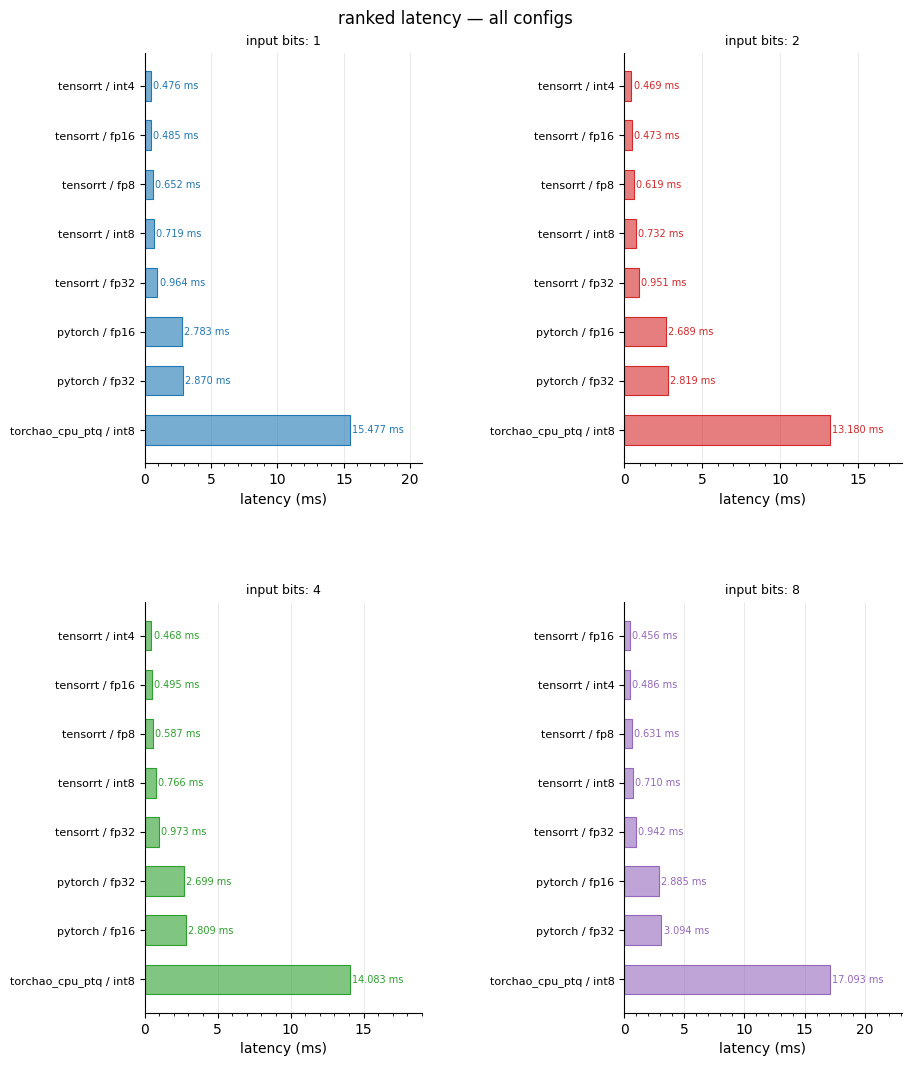

In [23]:
# ── Cell 7: Plot 6 — ranked latency chart (one subplot per input_bits) ────────

ranked = (
    table
    .sort_values("lat_ms")
    .reset_index(drop=True)
)
ranked["label"] = ranked["backend"] + " / " + ranked["precision"]
ranked["input_bits"] = ranked["input_bits"].astype(int)

active_bits = sorted(ranked["input_bits"].unique())
n = len(active_bits)
nrows = math.ceil(n / COLS)

fig, axes = plt.subplots(
    nrows, COLS,
    figsize=(4.5 * COLS, 0),   # height set below
    constrained_layout=True,
    squeeze=False,
)

# dynamic figure height based on number of bars per subplot
max_bars = ranked.groupby("input_bits").size().max()
fig.set_size_inches(4.5 * COLS, max_bars * 0.55 * nrows + 1.5)

fig.suptitle("ranked latency — all configs", fontsize=12,
             x=0.5, ha="center", y=1.02)
fig.set_constrained_layout_pads(wspace=0.15, hspace=0.15)

ax_flat = axes.flatten()
for idx in range(n, len(ax_flat)):
    ax_flat[idx].set_visible(False)

for ax, bits in zip(ax_flat, active_bits):
    grp = ranked[ranked["input_bits"] == bits].sort_values("lat_ms").reset_index(drop=True)

    if grp.empty:
        ax.set_visible(False)
        continue

    color = BIT_PALETTE.get(bits, "#7f7f7f")
    y_pos = np.arange(len(grp))

    ax.barh(y_pos, grp["lat_ms"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.6, zorder=2)

    # latency value at the end of each bar
    for yi, (_, row) in enumerate(grp.iterrows()):
        ax.text(row["lat_ms"] + ax.get_xlim()[1] * 0.01, yi,
                f"{row['lat_ms']:.3f} ms",
                ha="left", va="center", fontsize=7, color=color, zorder=4)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(grp["label"], fontsize=8)
    ax.set_title(f"input bits: {bits}", fontsize=9)
    ax.set_xlabel("latency (ms)")
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # set xlim with padding for the text labels
    ax.set_xlim(0, grp["lat_ms"].max() * 1.35)

plt.show()

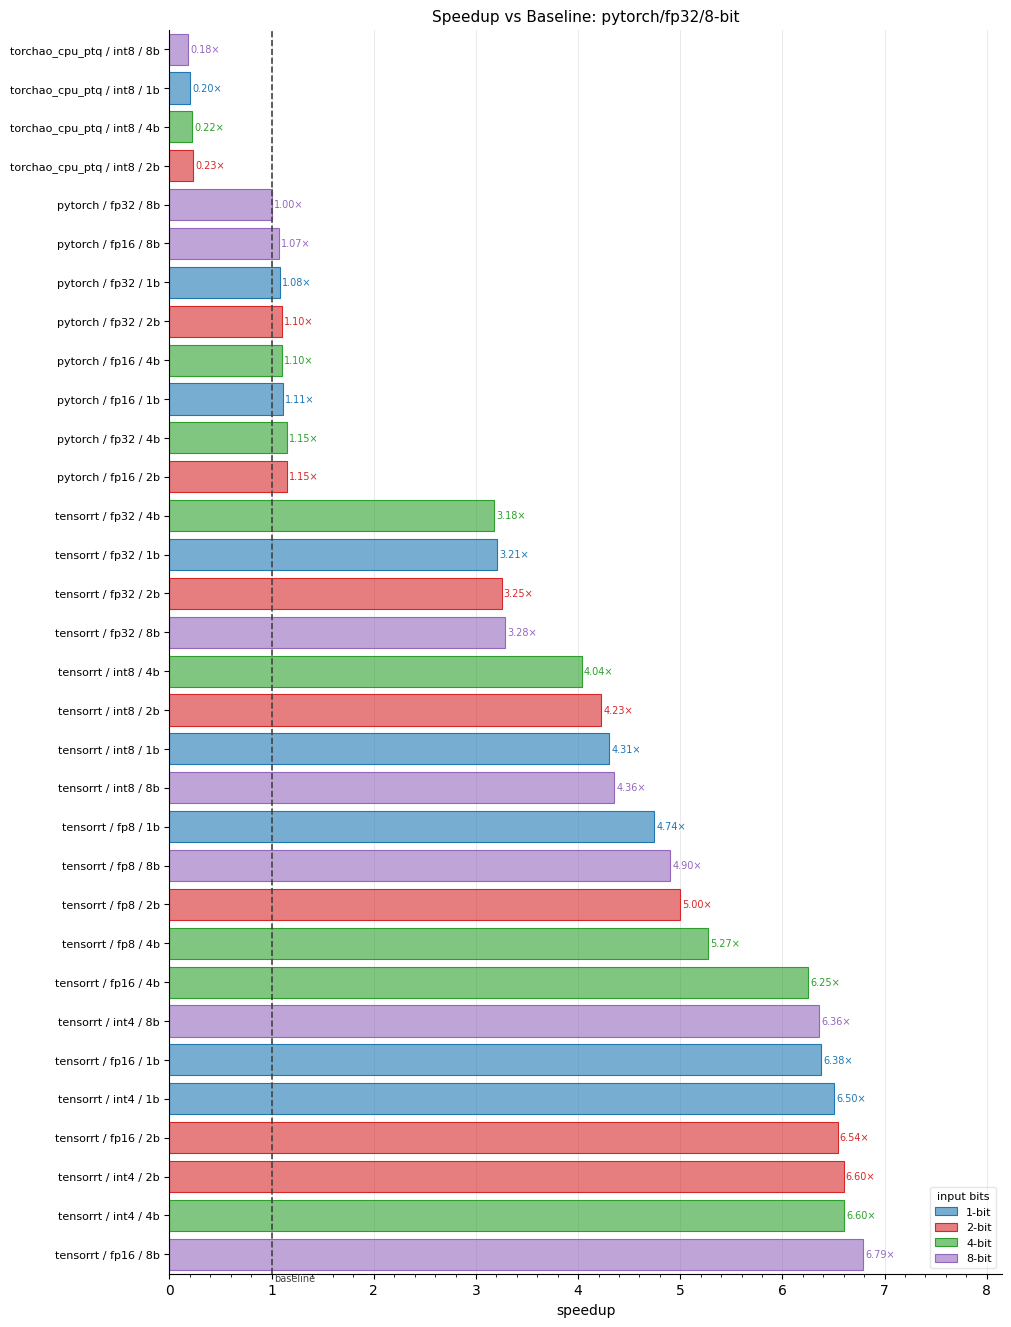

In [24]:
# ── Cell 8: Plot 8 — speedup vs baseline (pytorch / fp32 / 8-bit) ─────────────

# extract baseline latency
baseline = table[
    (table["backend"] == "pytorch") &
    (table["precision"] == "fp32") &
    (table["input_bits"] == 8)
]["lat_ms"].values[0]

# compute speedup for all configs
speedup = table.copy()
speedup["speedup"]    = baseline / speedup["lat_ms"]
speedup["label"]      = (speedup["backend"] + " / " +
                         speedup["precision"] + " / " +
                         speedup["input_bits"].astype(int).astype(str) + "b")
speedup["input_bits"] = speedup["input_bits"].astype(int)

# sort descending by speedup (fastest at top)
speedup = speedup.sort_values("speedup", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(speedup) * 0.38 + 1.0), constrained_layout=True)

for yi, (_, row) in enumerate(speedup.iterrows()):
    bits  = int(row["input_bits"])
    color = BIT_PALETTE.get(bits, "#7f7f7f")
    ax.barh(yi, row["speedup"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.8, zorder=2)
    ax.text(row["speedup"] + 0.02, yi,
            f"{row['speedup']:.2f}×",
            ha="left", va="center", fontsize=7, color=color, zorder=4)

# baseline reference line at y = 1
ax.axvline(x=1.0, color="#444444", linewidth=1.2,
           linestyle="--", zorder=3, label="baseline")
ax.text(1.02, len(speedup) - 0.5, "baseline",
        ha="left", va="top", fontsize=7, color="#444444")

ax.set_yticks(np.arange(len(speedup)))
ax.set_yticklabels(speedup["label"], fontsize=8)
ax.set_xlabel("speedup")
ax.set_title("Speedup vs Baseline: pytorch/fp32/8-bit", fontsize=11)
ax.set_xlim(0, speedup["speedup"].max() * 1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
ax.set_ylim(-0.5, len(speedup) - 0.5)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# legend for input_bits
present_bits = sorted(b for b in BIT_PALETTE if b in speedup["input_bits"].values)
handles = [
    plt.Rectangle((0, 0), 1, 1,
                  facecolor=BIT_PALETTE[b] + "99",
                  edgecolor=BIT_PALETTE[b], linewidth=0.8,
                  label=f"{b}-bit")
    for b in present_bits
]
ax.legend(handles=handles, title="input bits", fontsize=8,
          title_fontsize=8, framealpha=0.5, loc="lower right")

plt.show()